In [3]:
!pip install tensorflow

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9259 - loss: 0.2588
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9663 - loss: 0.1131
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9769 - loss: 0.0776
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9823 - loss: 0.0588
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9862 - loss: 0.0442
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9791 - loss: 0.0718
Test Accuracy: 0.9790999889373779
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Digit: 7
Actual Digit: 7


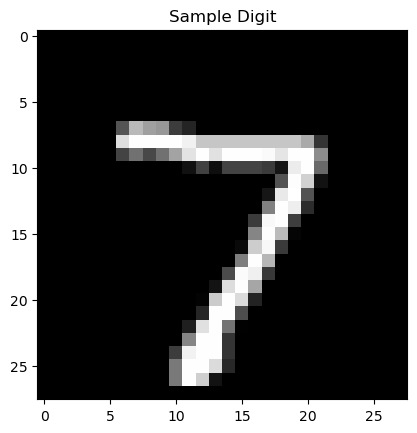

In [6]:
# =====================================
# STEP 1: Import Required Libraries
# =====================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

# =====================================
# STEP 2: Load MNIST Dataset (Inbuilt)
# =====================================
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# =====================================
# STEP 3: Normalize Data (0–255 → 0–1)
# =====================================
X_train = X_train / 255.0
X_test = X_test / 255.0

# =====================================
# STEP 4: Build Neural Network Model
# =====================================
model = Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# =====================================
# STEP 5: Compile Model
# =====================================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =====================================
# STEP 6: Train Model
# =====================================
model.fit(X_train, y_train, epochs=5)

# =====================================
# STEP 7: Evaluate Model
# =====================================
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

# =====================================
# STEP 8: Make Predictions
# =====================================
predictions = model.predict(X_test)

# Show prediction example
print("Predicted Digit:", np.argmax(predictions[0]))
print("Actual Digit:", y_test[0])

# =====================================
# STEP 9: Display Image
# =====================================
plt.imshow(X_test[0], cmap='gray')
plt.title("Sample Digit")
plt.show()